In [8]:
# Import required libraries
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [9]:
# Generate realistic mock data for behavioral risk prediction
np.random.seed(42) # Ensures we get the same random data every time

data = {
    'age': np.random.randint(18, 60, 1000),
    'key_population': np.random.choice(['MSM', 'PWID', 'FSW', 'Migrant', 'General'], 1000),
    'random_sex_count': np.random.randint(0, 15, 1000),
    'condom_use_freq': np.random.choice(['Never', 'Sometimes', 'Always'], 1000),
    'shared_syringe': np.random.choice([0, 1], 1000, p=[0.8, 0.2]),
    'months_since_last_test': np.random.randint(1, 60, 1000),
    'sti_history': np.random.choice([0, 1], 1000, p=[0.7, 0.3]),
    
    # Target Variable: 0 = Low Risk, 1 = PrEP Needed, 2 = PEP Needed, 3 = Urgent Diagnosis Needed
    'target_action': np.random.choice([0, 1, 2, 3], 1000) 
}

df = pd.DataFrame(data)
print("Dataset generated! Here are the first 5 rows:")
display(df.head())

Dataset generated! Here are the first 5 rows:


,age,key_population,random_sex_count,condom_use_freq,shared_syringe,months_since_last_test,sti_history,target_action
0,56,General,7,Sometimes,0,15,0,3
1,46,Migrant,7,Never,0,46,1,1
2,32,Migrant,0,Never,1,25,1,3
3,25,General,9,Never,1,21,0,1
4,38,PWID,10,Always,0,24,0,2


In [10]:
# Initialize LabelEncoder to convert categorical text into numeric codes
le = LabelEncoder()

# Apply encoding to categorical columns
categorical_cols = ['key_population', 'condom_use_freq']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Separate the Features (X) from the Target (y)
X = df.drop('target_action', axis=1)
y = df['target_action']

# Split data into 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data split successful!")
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Data split successful!
Training data shape: (800, 7)
Testing data shape: (200, 7)


In [11]:
# Define the XGBoost Classifier model
model = xgb.XGBClassifier(
    objective='multi:softprob',  # Used for predicting multiple categories
    num_class=4,                 # 4 categories (Low Risk, PrEP, PEP, Diagnosis)
    eval_metric='mlogloss', 
    max_depth=5, 
    learning_rate=0.1, 
    n_estimators=100,
    random_state=42
)

# Train the model using the training data
model.fit(X_train, y_train)

print("Model Training Complete! The 'model' variable is now ready to make predictions.")

Model Training Complete! The 'model' variable is now ready to make predictions.


Accuracy: 0.25

Classification Report:
               precision    recall  f1-score   support

           0       0.21      0.23      0.22        44
           1       0.26      0.25      0.25        53
           2       0.30      0.28      0.29        54
           3       0.23      0.24      0.24        49

    accuracy                           0.25       200
   macro avg       0.25      0.25      0.25       200
weighted avg       0.25      0.25      0.25       200



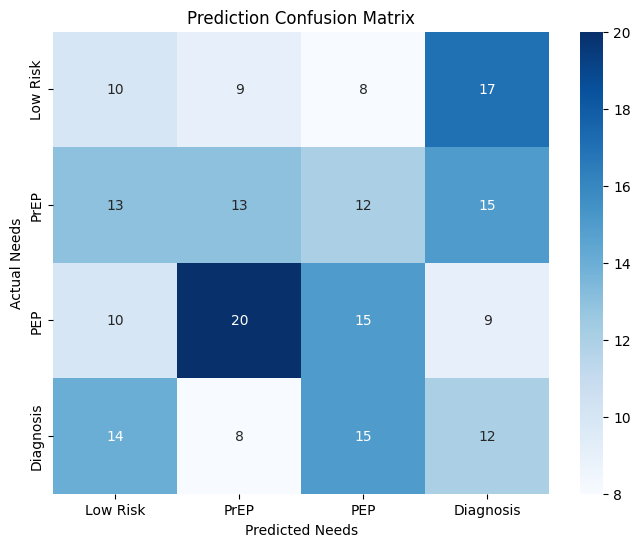

In [12]:
# 1. Make predictions using the trained model
y_pred = model.predict(X_test)

# 2. Print accuracy and detailed classification report
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 3. Plot the confusion matrix to see where the model gets confused
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Low Risk', 'PrEP', 'PEP', 'Diagnosis'],
            yticklabels=['Low Risk', 'PrEP', 'PEP', 'Diagnosis'])
plt.title('Prediction Confusion Matrix')
plt.ylabel('Actual Needs')
plt.xlabel('Predicted Needs')
plt.show()

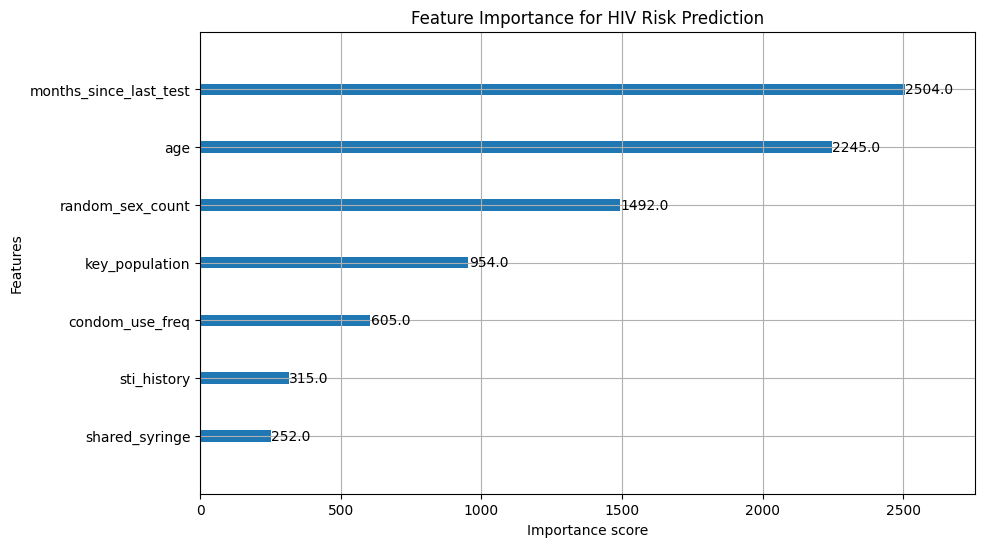

In [13]:
# Plot which behavioral factors the model relied on the most
plt.figure(figsize=(10,6))
xgb.plot_importance(model, importance_type='weight', max_num_features=10, ax=plt.gca())
plt.title('Feature Importance for HIV Risk Prediction')
plt.show()

In [16]:
import joblib
from IPython.display import FileLink, display

# 1. Save the model and label encoder to the Kaggle working directory
joblib.dump(model, 'hiv_risk_model.pkl')
joblib.dump(le, 'label_encoder.pkl')

print("Files saved successfully! Click the links below to download:")

# 2. Generate native Kaggle download links
display(FileLink('hiv_risk_model.pkl'))
display(FileLink('label_encoder.pkl'))

Files saved successfully! Click the links below to download:


/kaggle/working/hiv_risk_model.pkl

/kaggle/working/label_encoder.pkl